In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from pathlib import Path

data_path = Path("heart-disease-cleveland.csv")
url = "https://raw.githubusercontent.com/dataprofessor/data/master/heart-disease-cleveland.csv"

feature_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal"
]
column_names = feature_names + ["diagnosis"]

data_source = data_path if data_path.exists() else url

df = pd.read_csv(
    data_source,
    names=column_names,
    header=0,
    na_values="?"
)

# binary classification
df["diagnosis"] = df["diagnosis"].astype(int)
df["diagnosis"] = df["diagnosis"].apply(lambda x: 1 if x > 0 else 0)

X_df = df[feature_names].copy()
y = df["diagnosis"]

# handle missing
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_df),
    columns=feature_names,
    index=X_df.index,
)

# split
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

# scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df)
X_test = scaler.transform(X_test_df)

X_train_scaled_df = pd.DataFrame(X_train, columns=feature_names, index=X_train_df.index)
X_test_scaled_df = pd.DataFrame(X_test, columns=feature_names, index=X_test_df.index)

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Logistic Regression
Accuracy: 0.8688524590163934
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [3]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Decision Tree
Accuracy: 0.7213114754098361
              precision    recall  f1-score   support

           0       0.81      0.64      0.71        33
           1       0.66      0.82      0.73        28

    accuracy                           0.72        61
   macro avg       0.73      0.73      0.72        61
weighted avg       0.74      0.72      0.72        61



In [4]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Random Forest
Accuracy: 0.8852459016393442
              precision    recall  f1-score   support

           0       0.96      0.82      0.89        33
           1       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61



In [5]:
results = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [0.8688, 0.7213, 0.8852]
}

import pandas as pd
pd.DataFrame(results)

,Model,Accuracy
0,Logistic Regression,0.8688
1,Decision Tree,0.7213
2,Random Forest,0.8852


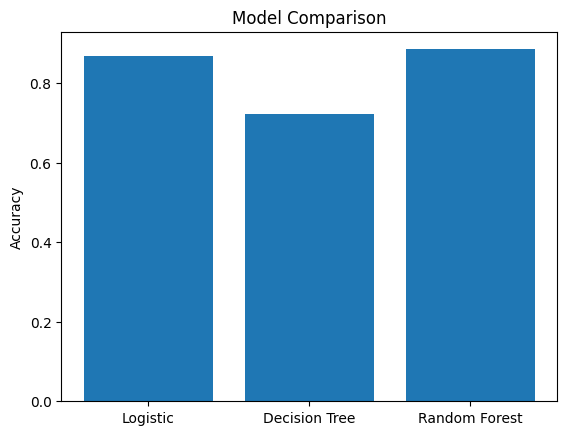

In [6]:
import matplotlib.pyplot as plt

models = ["Logistic", "Decision Tree", "Random Forest"]
accuracy = [0.8688, 0.7213, 0.8852]

plt.bar(models, accuracy)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

In [7]:
# ===== Experiment: Logistic Regression (balanced) =====

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Logistic Regression (balanced)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Logistic Regression (balanced)
Accuracy: 0.8688524590163934
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [8]:
# ===== Experiment: Random Forest (balanced) =====

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Random Forest (balanced)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Random Forest (balanced)
Accuracy: 0.9016393442622951
              precision    recall  f1-score   support

           0       0.94      0.88      0.91        33
           1       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



In [9]:
print("Model Comparison Summary")
print("Logistic Regression: acc=0.87, recall1=0.93")
print("Random Forest: acc=0.89, recall1=0.96")
print("Random Forest (balanced): acc=0.90, recall1=0.93")
print("XGBoost: run cell above for results")

Model Comparison Summary
Logistic Regression: acc=0.87, recall1=0.93
Random Forest: acc=0.89, recall1=0.96
Random Forest (balanced): acc=0.90, recall1=0.93
XGBoost: run cell above for results


In [10]:
from sklearn.metrics import confusion_matrix

rf_bal_pred = model.predict(X_test)
print("Random Forest (balanced) confusion matrix:")
print(confusion_matrix(y_test, rf_bal_pred))

Random Forest (balanced) confusion matrix:
[[29  4]
 [ 2 26]]


In [11]:
# ===== XGBoost =====
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    verbosity=0,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost
Accuracy: 0.8852459016393442
              precision    recall  f1-score   support

           0       0.96      0.82      0.89        33
           1       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61



In [12]:
# ===== SHAP Explainability For Each Model =====
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

explainability_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        verbosity=0,
    ),
}

trained_explainability_models = {}
for model_name, current_model in explainability_models.items():
    current_model.fit(X_train, y_train)
    trained_explainability_models[model_name] = current_model

sample_size = min(80, len(X_test_scaled_df))
X_explain = X_test_scaled_df.iloc[:sample_size].copy()
print(f"Using {len(X_explain)} test rows for SHAP visualizations.")

Using 61 test rows for SHAP visualizations.



SHAP explainability for Logistic Regression


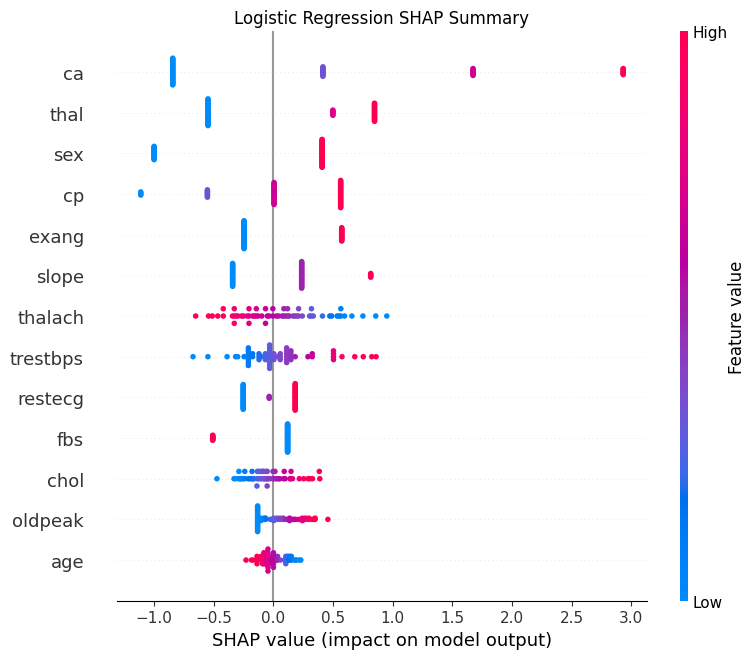

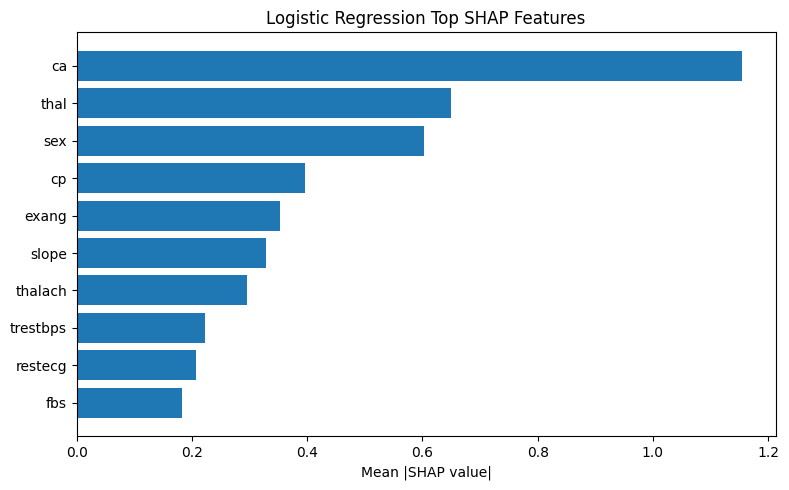


SHAP explainability for Decision Tree


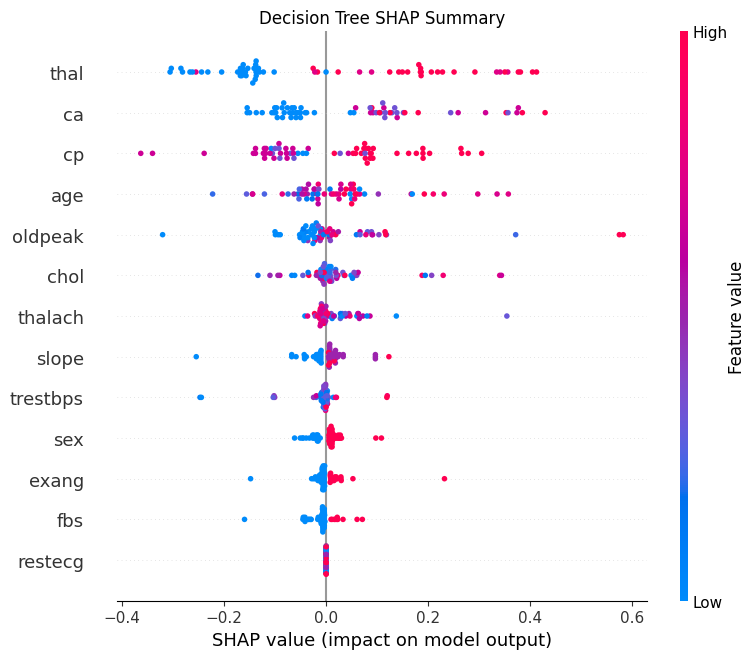

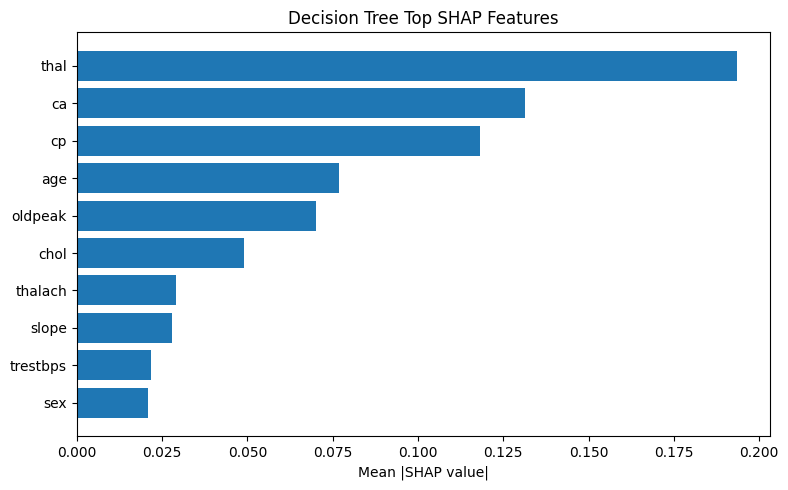


SHAP explainability for Random Forest


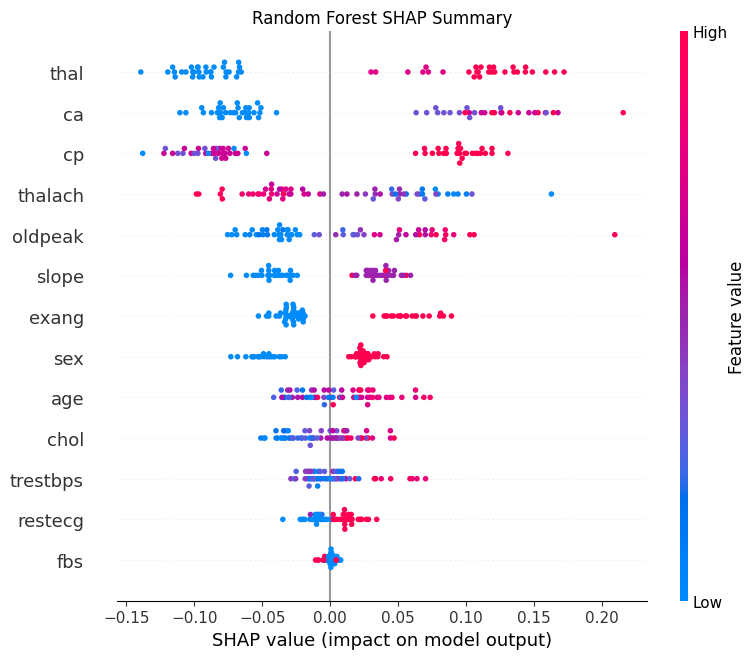

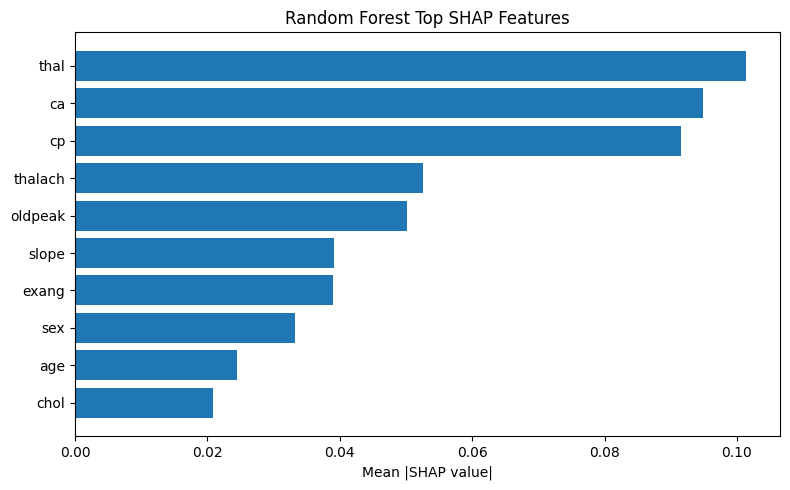


SHAP explainability for XGBoost


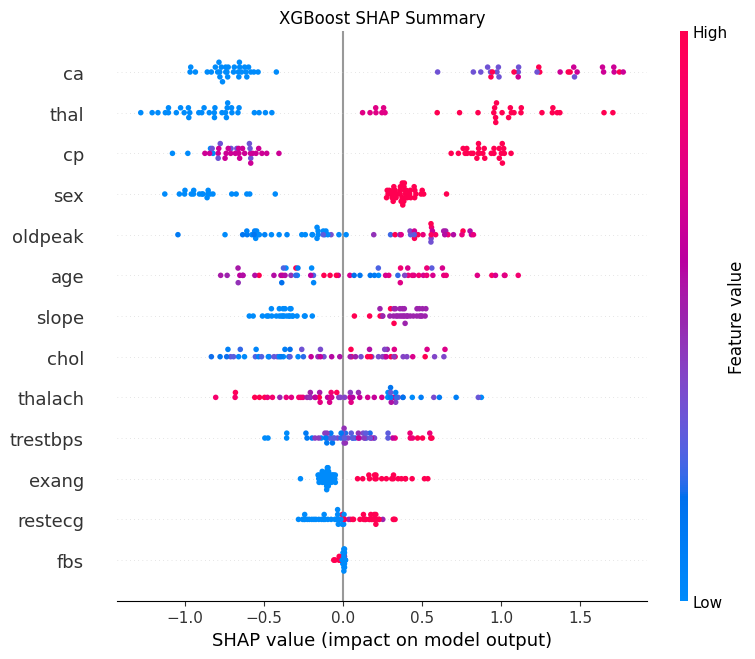

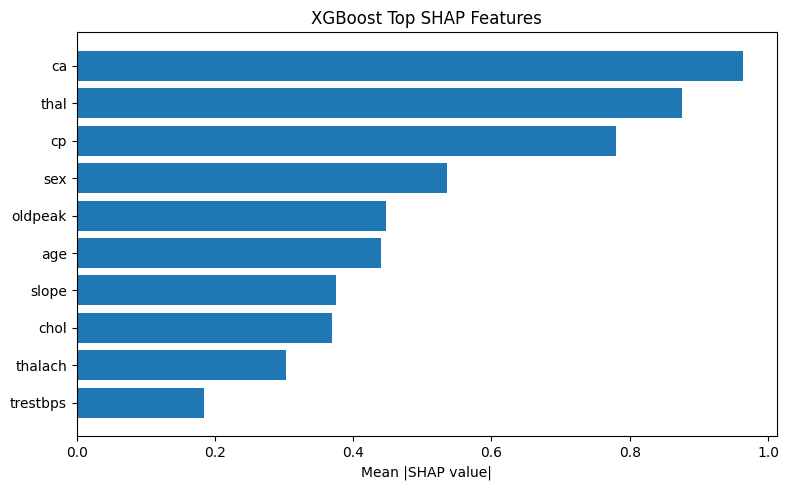

In [13]:
# Plot SHAP summary + top-feature bar chart for each model
for model_name, current_model in trained_explainability_models.items():
    print(f"\nSHAP explainability for {model_name}")

    if model_name in {"Decision Tree", "Random Forest", "XGBoost"}:
        explainer = shap.TreeExplainer(current_model)
        shap_values = explainer.shap_values(X_explain)
        if isinstance(shap_values, list):
            shap_values_to_plot = shap_values[1]
        elif getattr(shap_values, "ndim", 0) == 3:
            shap_values_to_plot = shap_values[:, :, 1]
        else:
            shap_values_to_plot = shap_values
    else:
        background = shap.sample(X_train_scaled_df, min(100, len(X_train_scaled_df)), random_state=42)
        explainer = shap.LinearExplainer(current_model, background)
        shap_values = explainer.shap_values(X_explain)
        shap_values_to_plot = shap_values[1] if isinstance(shap_values, list) else shap_values

    shap.summary_plot(shap_values_to_plot, X_explain, plot_type="dot", show=False)
    plt.title(f"{model_name} SHAP Summary")
    plt.tight_layout()
    plt.show()

    mean_abs_shap = np.abs(shap_values_to_plot).mean(axis=0)
    importance_df = (
        pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs_shap})
        .sort_values("mean_abs_shap", ascending=False)
        .head(10)
    )

    plt.figure(figsize=(8, 5))
    plt.barh(importance_df["feature"][::-1], importance_df["mean_abs_shap"][::-1])
    plt.xlabel("Mean |SHAP value|")
    plt.title(f"{model_name} Top SHAP Features")
    plt.tight_layout()
    plt.show()